In [ ]:
#!pip install gdal fiona
!pip install rasterstats

  Using cached rasterstats-0.20.0-py3-none-any.whl.metadata (4.2 kB)
Using cached rasterstats-0.20.0-py3-none-any.whl (17 kB)

   ---------------------------------------- 0/2 [simplejson]
   ---------------------------------------- 0/2 [simplejson]
   ---------------------------------------- 0/2 [simplejson]
   ---------------------------------------- 0/2 [simplejson]
   -------------------- ------------------- 1/2 [rasterstats]
   ---------------------------------------- 2/2 [rasterstats]



INDICE COMPUTATION

Creating vineyard mask...
Indices saved to indices_output


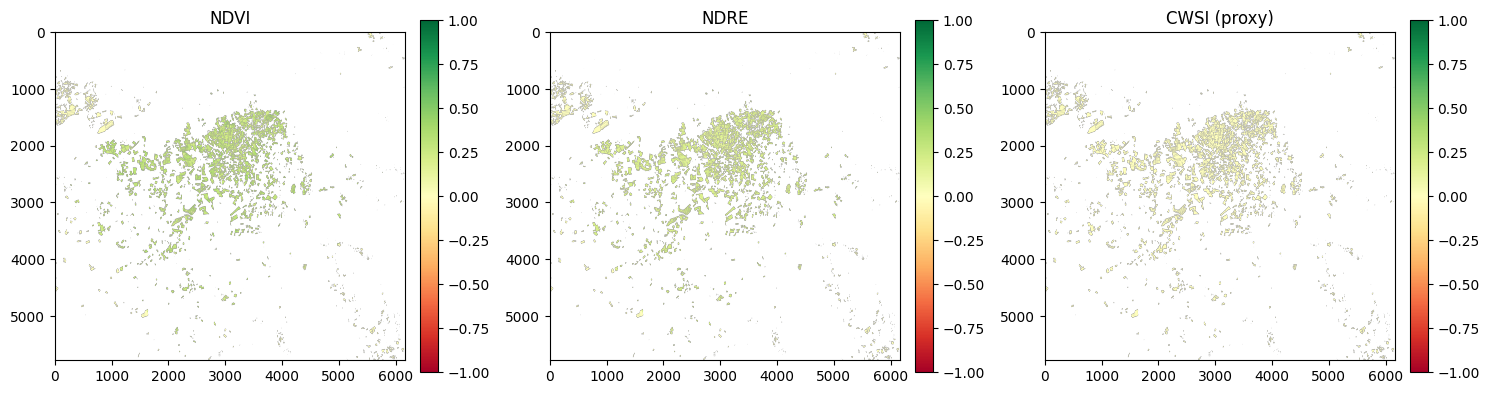

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os
import geopandas as gpd
from rasterio import features

# ============================================================
# 1. Define input band file paths (change these!)
# ============================================================
band_dir = r"D:\ITC MASTERS\YEAR 1\SEM 2\Quartile 3\Machine Learning\Practicals\Group Project\S2 Data\clipped_bands_newAOI"

# 10 m bands
b2_path = os.path.join(band_dir, 'band2_aoi.tif')
b3_path = os.path.join(band_dir, 'band3_aoi.tif')
b4_path = os.path.join(band_dir, 'band4_aoi.tif')
b8_path = os.path.join(band_dir, 'band8_aoi.tif')

# 20 m bands
b5_path  = os.path.join(band_dir, 'band5_aoi.tif')
b8a_path = os.path.join(band_dir, 'band8A_aoi.tif')
b11_path = os.path.join(band_dir, 'band11_aoi.tif')

# Vineyard polygon shapefile (replace with your actual path)
shapefile_path = r"D:\ITC MASTERS\YEAR 1\SEM 2\Quartile 3\Machine Learning\Practicals\Group Project\Leon_vineyards_clip\leon_valid_polygons.geojson"   # <-- CHANGE THIS

# Output directory for indices
output_dir = 'indices_output'
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# 2. Function to resample a band to 10 m (nearest neighbour)
# ============================================================
def resample_to_10m(src_path, ref_path, dst_path):
    """Resample a 20m band to 10m using the reference band's grid."""
    with rasterio.open(src_path) as src:
        with rasterio.open(ref_path) as ref:
            transform = ref.transform
            shape = (ref.height, ref.width)
            data = src.read(1, out_shape=shape, resampling=rasterio.enums.Resampling.nearest)
            profile = src.profile.copy()
            profile.update({
                'transform': transform,
                'width': shape[1],
                'height': shape[0],
                'crs': ref.crs
            })
            with rasterio.open(dst_path, 'w', **profile) as dst:
                dst.write(data, 1)
    return dst_path

# ============================================================
# 3. Read the 10 m bands (we'll use B4 as reference for mask)
# ============================================================
with rasterio.open(b4_path) as src:
    B4 = src.read(1).astype(np.float32)
    profile = src.profile   # use this as template for outputs
    transform = src.transform
    width = src.width
    height = src.height
    crs = src.crs

with rasterio.open(b2_path) as src:
    B2 = src.read(1).astype(np.float32)
with rasterio.open(b3_path) as src:
    B3 = src.read(1).astype(np.float32)
with rasterio.open(b8_path) as src:
    B8 = src.read(1).astype(np.float32)

# ============================================================
# 4. Create a mask from the vineyard polygons (rasterize)
# ============================================================
print("Creating vineyard mask...")
gdf = gpd.read_file(shapefile_path)
# Ensure CRS matches the bands
if gdf.crs != crs:
    gdf = gdf.to_crs(crs)

# Rasterize: 1 = inside any polygon, 0 = outside
shapes = ((geom, 1) for geom in gdf.geometry)
mask = features.rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype=np.uint8
)

# Apply mask to the bands: set outside polygons to NaN
B4 = np.where(mask == 1, B4, np.nan)
B2 = np.where(mask == 1, B2, np.nan)
B3 = np.where(mask == 1, B3, np.nan)
B8 = np.where(mask == 1, B8, np.nan)

# ============================================================
# 5. Resample 20 m bands to 10 m and apply mask
# ============================================================
temp_b5 = os.path.join(output_dir, 'temp_B5_10m.tif')
temp_b8a = os.path.join(output_dir, 'temp_B8A_10m.tif')
temp_b11 = os.path.join(output_dir, 'temp_B11_10m.tif')

resample_to_10m(b5_path, b4_path, temp_b5)
resample_to_10m(b8a_path, b4_path, temp_b8a)
resample_to_10m(b11_path, b4_path, temp_b11)

with rasterio.open(temp_b5) as src:
    B5 = src.read(1).astype(np.float32)
with rasterio.open(temp_b8a) as src:
    B8A = src.read(1).astype(np.float32)
with rasterio.open(temp_b11) as src:
    B11 = src.read(1).astype(np.float32)

# Apply the same mask to these bands
B5 = np.where(mask == 1, B5, np.nan)
B8A = np.where(mask == 1, B8A, np.nan)
B11 = np.where(mask == 1, B11, np.nan)

# ============================================================
# 6. Compute indices (avoid division by zero)
# ============================================================
eps = 1e-10

# NDVI = (NIR - Red) / (NIR + Red)
NDVI = (B8 - B4) / (B8 + B4 + eps)

# NDRE = (NIR (865 nm) - RedEdge (705 nm)) / (NIR + RedEdge)
NDRE = (B8A - B5) / (B8A + B5 + eps)

# CWSI proxy (water stress) = (NIR - SWIR1) / (NIR + SWIR1)
CWSI = (B8A - B11) / (B8A + B11 + eps)

# ============================================================
# 7. Save the indices as GeoTIFFs (preserving NoData as NaN)
# ============================================================
out_profile = profile.copy()
out_profile.update({'count': 1, 'dtype': 'float32', 'nodata': np.nan})

with rasterio.open(os.path.join(output_dir, 'NDVI.tif'), 'w', **out_profile) as dst:
    dst.write(NDVI, 1)
with rasterio.open(os.path.join(output_dir, 'NDRE.tif'), 'w', **out_profile) as dst:
    dst.write(NDRE, 1)
with rasterio.open(os.path.join(output_dir, 'CWSI.tif'), 'w', **out_profile) as dst:
    dst.write(CWSI, 1)

print(f"Indices saved to {output_dir}")

# ============================================================
# 8. Plot the three indices (only vineyard areas shown)
# ============================================================
# For plotting, we mask NaN values (they will be transparent)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Mask for display
ndvi_masked = np.ma.masked_invalid(NDVI)
ndre_masked = np.ma.masked_invalid(NDRE)
cwsi_masked = np.ma.masked_invalid(CWSI)

im1 = axes[0].imshow(ndvi_masked, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0].set_title('NDVI')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(ndre_masked, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_title('NDRE')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

im3 = axes[2].imshow(cwsi_masked, cmap='RdYlGn', vmin=-1, vmax=1)
axes[2].set_title('CWSI (proxy)')
plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'indices_plot.png'), dpi=300)
plt.show()

# Clean up temporary resampled files
os.remove(temp_b5)
os.remove(temp_b8a)
os.remove(temp_b11)

RANDOM FOREST FEATURE IMPORTANCE USING UNSUPERVISED LEARNING AND KMEANS

Computing zonal statistics...
Valid polygons after removing missing values: 3151
Cluster sizes:
cluster
2    1462
0    1185
1     504
Name: count, dtype: int64
Saved 3151 polygons to indices_output\indices_with_clusters.csv

Random Forest accuracy: 0.986

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       356
           1       1.00      0.99      0.99       151
           2       0.99      0.99      0.99       439

    accuracy                           0.99       946
   macro avg       0.99      0.99      0.99       946
weighted avg       0.99      0.99      0.99       946


Feature importances (ranking of indices):
NDVI: 0.5042
NDRE: 0.4958
CWSI: 0.0000


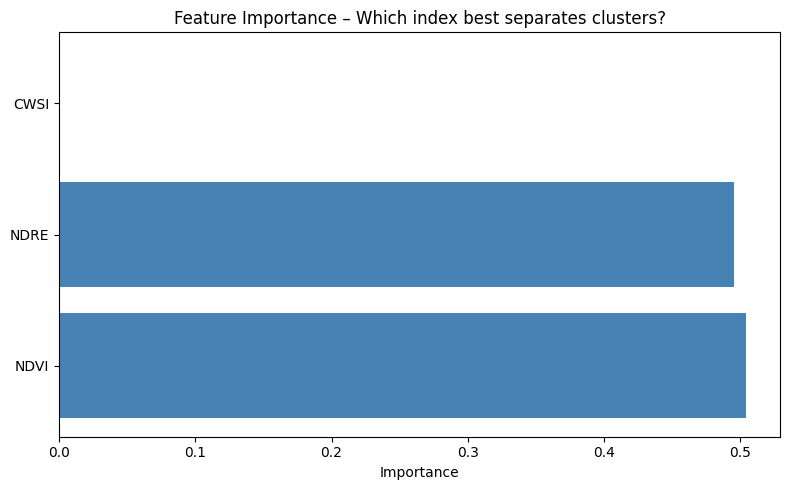

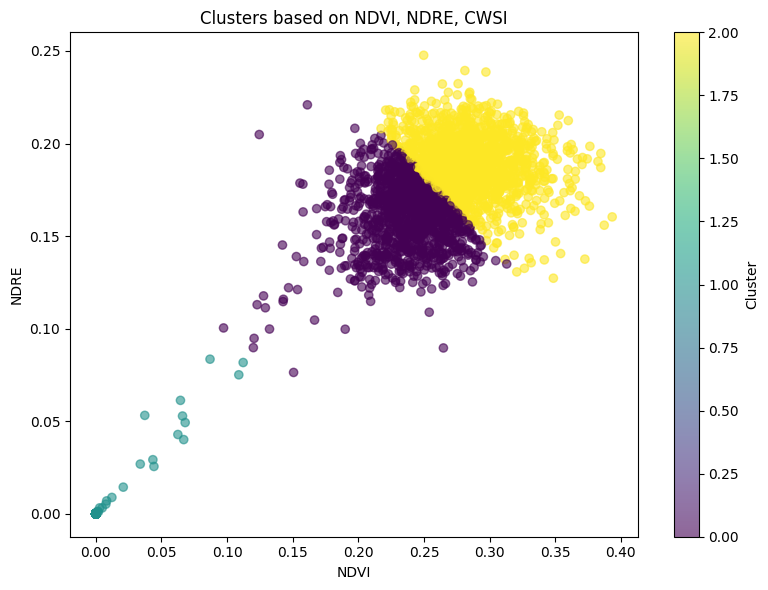

Saved 3151 polygons to indices_output\indices_with_clusters.csv


In [4]:
import geopandas as gpd
import pandas as pd
import numpy as np
from rasterstats import zonal_stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. File paths – adjust these to your data
# ============================================================
shapefile_path = r"D:\ITC MASTERS\YEAR 1\SEM 2\Quartile 3\Machine Learning\Practicals\Group Project\Leon_vineyards_clip\leon_valid_polygons.geojson"                # polygon shapefile
raster_paths = {
    'NDVI': r"D:\ITC MASTERS\YEAR 1\SEM 2\Quartile 3\Machine Learning\Practicals\Group Project\indices_output\NDVI.tif",
    'NDRE': r"D:\ITC MASTERS\YEAR 1\SEM 2\Quartile 3\Machine Learning\Practicals\Group Project\indices_output\NDRE.tif",
    'CWSI': r"D:\ITC MASTERS\YEAR 1\SEM 2\Quartile 3\Machine Learning\Practicals\Group Project\indices_output\CWSI.tif"
}
output_csv = r"D:\ITC MASTERS\YEAR 1\SEM 2\Quartile 3\Machine Learning\Practicals\Group Project\indices_output"        # where to save the results

import os

# Ensure output directory exists
output_dir = 'indices_output'
os.makedirs(output_dir, exist_ok=True)
output_csv = os.path.join(output_dir, 'indices_with_clusters.csv')

# ============================================================
# 2. Load polygons and ensure a unique ID column
# ============================================================
gdf = gpd.read_file(shapefile_path)
if 'id' not in gdf.columns:
    gdf['id'] = range(1, len(gdf) + 1)          # create numeric ID if missing

# ============================================================
# 3. Compute mean of each raster inside each polygon
# ============================================================
print("Computing zonal statistics...")
results = []
for idx, row in gdf.iterrows():
    poly_id = row['id']
    stats = {}
    for name, raster_path in raster_paths.items():
        zs = zonal_stats(row.geometry, raster_path, stats=['mean'], all_touched=False)
        mean_val = zs[0]['mean']
        if mean_val is None or np.isnan(mean_val):
            mean_val = np.nan
        stats[name] = mean_val
    results.append({'polygon_id': poly_id, **stats})

df = pd.DataFrame(results)

# Drop rows with any missing index (polygons outside raster extent)
df = df.dropna(subset=['NDVI', 'NDRE', 'CWSI'])
print(f"Valid polygons after removing missing values: {len(df)}")

# ============================================================
# 4. Standardise the features for clustering
# ============================================================
features = ['NDVI', 'NDRE', 'CWSI']
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 5. Apply K‑means clustering
# ============================================================
# Choose number of clusters. You can use the elbow method, but here we set 3.
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the dataframe
df['cluster'] = clusters

print("Cluster sizes:")
print(df['cluster'].value_counts())

# ============================================================
# 6. Save the data with cluster labels (optional)
# ============================================================
df.to_csv(output_csv, index=False)
print(f"Saved {len(df)} polygons to {output_csv}")

# ============================================================
# 7. Train Random Forest to predict clusters from original indices
# ============================================================
X_rf = df[features].values
y = df['cluster'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y, test_size=0.3, random_state=42, stratify=y
)

# Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# Evaluation
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nRandom Forest accuracy: {acc:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature importance
importances = rf.feature_importances_
print("\nFeature importances (ranking of indices):")
for name, imp in zip(features, importances):
    print(f"{name}: {imp:.4f}")

# Plot
plt.figure(figsize=(8,5))
plt.barh(features, importances, color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance – Which index best separates clusters?')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# ============================================================
# 8. (Optional) Visualise clusters in 2D (first two indices)
# ============================================================
plt.figure(figsize=(8,6))
scatter = plt.scatter(df['NDVI'], df['NDRE'], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('NDVI')
plt.ylabel('NDRE')
plt.title('Clusters based on NDVI, NDRE, CWSI')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150)
plt.show()

# Save the data with cluster labels
df.to_csv(output_csv, index=False)
print(f"Saved {len(df)} polygons to {output_csv}")

STENCIL CREATION

NDVI thresholds: low=0.219, high=0.280
NDRE thresholds: low=0.156, high=0.193
CWSI thresholds: low=0.000, high=0.000
Reading rasters...
Valid pixels inside vineyards: 2034912 / 35639480
Stencil saved to D:\ITC MASTERS\YEAR 1\SEM 2\Quartile 3\Machine Learning\Practicals\Group Project\indices_output\health_stencil.tif


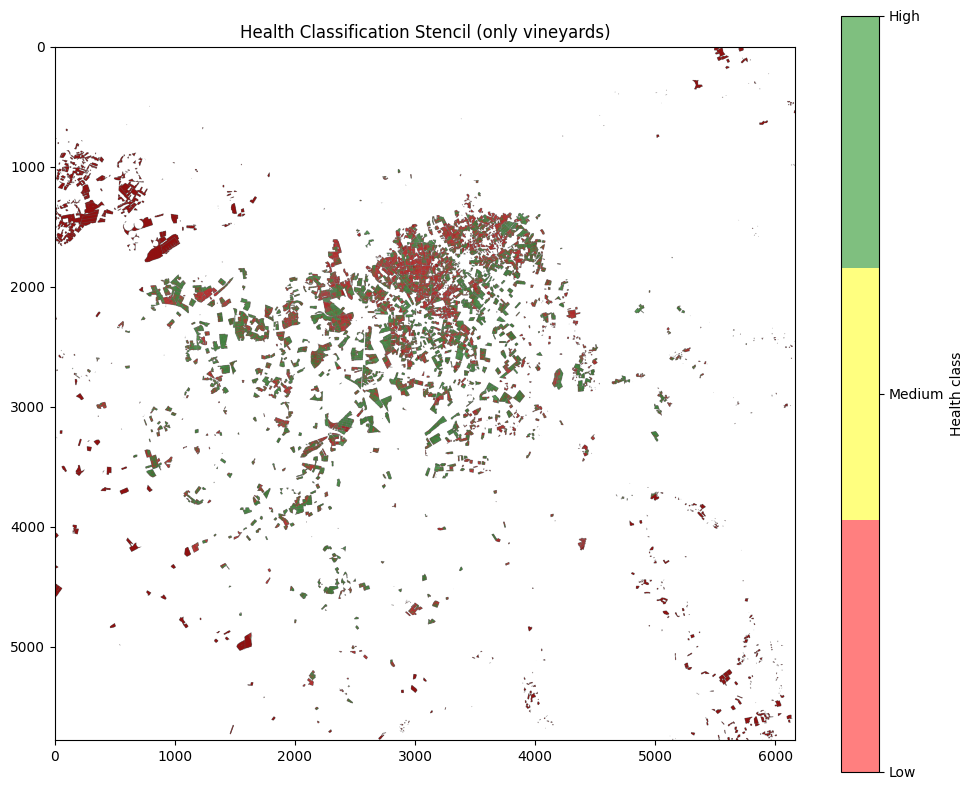

In [8]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os

# ============================================================
# 1. Configuration – adjust these paths
# ============================================================
input_dir = r"D:\ITC MASTERS\YEAR 1\SEM 2\Quartile 3\Machine Learning\Practicals\Group Project\indices_output"   # folder containing the index rasters
output_dir = r"D:\ITC MASTERS\YEAR 1\SEM 2\Quartile 3\Machine Learning\Practicals\Group Project\indices_output"  # same folder for output
os.makedirs(output_dir, exist_ok=True)

raster_files = {
    'NDVI': os.path.join(input_dir, 'NDVI.tif'),
    'NDRE': os.path.join(input_dir, 'NDRE.tif'),
    'CWSI': os.path.join(input_dir, 'CWSI.tif')
}

# ============================================================
# 2. Feature importances (use your actual values from clustering)
# ============================================================
importances = {
    'NDVI': 0.5042,   # example – use your own numbers
    'NDRE': 0.4958,
    'CWSI': 0.00
}
sorted_indices = sorted(importances.keys(), key=lambda x: importances[x], reverse=True)

# ============================================================
# 3. Classification thresholds (example – adjust as needed)
# ============================================================
# Option: compute from data percentiles (inside vineyards only)
def compute_thresholds(raster_path):
    """Return low and high thresholds from the valid pixels of a raster."""
    with rasterio.open(raster_path) as src:
        data = src.read(1)
        # Flatten and remove NaN
        data = data[~np.isnan(data)]
        if len(data) == 0:
            raise ValueError(f"No valid data in {raster_path}")
        p33, p67 = np.percentile(data, [33, 67])
        return p33, p67

thresholds = {}
for idx, path in raster_files.items():
    low, high = compute_thresholds(path)
    thresholds[idx] = {'low': low, 'high': high}
    print(f"{idx} thresholds: low={low:.3f}, high={high:.3f}")

# ============================================================
# 4. Read all index rasters and create a combined mask
# ============================================================
print("Reading rasters...")
arrays = {}
for idx, path in raster_files.items():
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        # Replace NoData (if stored as NaN) with NaN
        if src.nodata is not None:
            data = np.where(data == src.nodata, np.nan, data)
        arrays[idx] = data
        # Use the first raster for metadata
        if idx == sorted_indices[0]:
            profile = src.profile
            height, width = src.shape

# Create a mask of valid pixels (where all three indices are not NaN)
valid_mask = np.ones((height, width), dtype=bool)
for idx in sorted_indices:
    valid_mask &= ~np.isnan(arrays[idx])

print(f"Valid pixels inside vineyards: {np.sum(valid_mask)} / {height*width}")

# ============================================================
# 5. Classify each index individually (only on valid pixels)
# ============================================================
def classify_index(data, low, high):
    """Return 0=low, 1=medium, 2=high; NaN remains NaN."""
    result = np.full_like(data, np.nan, dtype=np.float32)
    result[data <= low] = 0
    result[(data > low) & (data <= high)] = 1
    result[data > high] = 2
    return result

class_arrays = {}
for idx in sorted_indices:
    class_arrays[idx] = classify_index(arrays[idx], thresholds[idx]['low'], thresholds[idx]['high'])

# ============================================================
# 6. Combine classifications using priority order
# ============================================================
final_class = np.full((height, width), 255, dtype=np.uint8)   # 255 = NoData

# Iterate over all valid pixels
for i in range(height):
    for j in range(width):
        if not valid_mask[i, j]:
            continue
        # Get class for each index at this pixel
        classes = {idx: class_arrays[idx][i, j] for idx in sorted_indices}
        # Apply priority rule: use first index that is not medium (1)
        final_cls = None
        for idx in sorted_indices:
            if classes[idx] != 1:          # not medium
                final_cls = classes[idx]
                break
        if final_cls is None:
            final_cls = 1                  # all medium
        final_class[i, j] = final_cls

# ============================================================
# 7. Save the stencil
# ============================================================
output_raster = os.path.join(output_dir, 'health_stencil.tif')
profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
with rasterio.open(output_raster, 'w', **profile) as dst:
    dst.write(final_class, 1)
print(f"Stencil saved to {output_raster}")

# ============================================================
# 8. Plot the stencil (translucent overlay)
# ============================================================
# Use one of the indices as background (e.g., NDVI)
background = arrays['NDVI']
# Mask NaN for display
background_masked = np.ma.masked_invalid(background)

# Create a masked version of the stencil (only vineyard pixels)
stencil_masked = np.ma.masked_where(final_class == 255, final_class)

# Colormap for health classes (red=low, yellow=medium, green=high)
colors = ['red', 'yellow', 'green']
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(10, 8))
# Show background (grayscale)
im_bg = ax.imshow(background_masked, cmap='gray', alpha=1.0)
# Overlay stencil with transparency
im_stencil = ax.imshow(stencil_masked, cmap=cmap, alpha=0.5, vmin=0, vmax=2)
cbar = plt.colorbar(im_stencil, ticks=[0, 1, 2], label='Health class')
cbar.ax.set_yticklabels(['Low', 'Medium', 'High'])
ax.set_title('Health Classification Stencil (only vineyards)')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'health_stencil_plot.png'), dpi=150)
plt.show()